In [1]:
!unzip /content/data.zip

Archive:  /content/data.zip
  inflating: split_dataset/class_weights.json  
  inflating: split_dataset/test/images/img_0818.png  
  inflating: split_dataset/test/images/img_0466.png  
  inflating: split_dataset/test/images/img_0495.png  
  inflating: split_dataset/test/images/img_0520.png  
  inflating: split_dataset/test/images/img_0683.png  
  inflating: split_dataset/test/images/img_0827.png  
  inflating: split_dataset/test/images/img_0847.png  
  inflating: split_dataset/test/images/img_0981.png  
  inflating: split_dataset/test/images/img_0082.png  
  inflating: split_dataset/test/images/img_0446.png  
  inflating: split_dataset/test/images/img_0824.png  
  inflating: split_dataset/val/images/img_0555.png  
  inflating: split_dataset/test/images/img_0680.png  
  inflating: split_dataset/val/images/img_0756.png  
  inflating: split_dataset/val/images/img_0602.png  
  inflating: split_dataset/val/images/img_0491.png  
  inflating: split_dataset/val/images/img_0889.png  
  inflating

In [2]:
pip install torch torchvision pillow

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
import os

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [5]:
class SegmentationDataset(Dataset):

    def __init__(self, image_dir, mask_dir, transform=None):

        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.images = os.listdir(image_dir)
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):

        img_path = os.path.join(self.image_dir, self.images[index])
        mask_path = os.path.join(self.mask_dir, self.images[index])

        image = Image.open(img_path).convert("L")
        mask = Image.open(mask_path).convert("L")

        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)

        mask = (mask > 0).float()

        return image, mask

In [6]:
transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor()
])

In [7]:
train_dataset = SegmentationDataset(
    "/content/split_dataset/train/images",
    "/content/split_dataset/train/masks",
    transform
)

val_dataset = SegmentationDataset(
    "/content/split_dataset/val/images",
    "/content/split_dataset/val/masks",
    transform
)

test_dataset = SegmentationDataset(
    "/content/split_dataset/test/images",
    "/content/split_dataset/test/masks",
    transform
)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

In [8]:
class DoubleConv(nn.Module):

    def __init__(self, in_c, out_c):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_c,out_c,3,padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c,out_c,3,padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self,x):
        return self.conv(x)

In [9]:
class UNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.down1 = DoubleConv(1,32)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(32,64)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(64,128)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(128,256)

        self.up3 = nn.ConvTranspose2d(256,128,2,stride=2)
        self.conv3 = DoubleConv(256,128)

        self.up2 = nn.ConvTranspose2d(128,64,2,stride=2)
        self.conv2 = DoubleConv(128,64)

        self.up1 = nn.ConvTranspose2d(64,32,2,stride=2)
        self.conv1 = DoubleConv(64,32)

        self.final = nn.Conv2d(32,1,1)

    def forward(self,x):

        d1 = self.down1(x)
        p1 = self.pool1(d1)

        d2 = self.down2(p1)
        p2 = self.pool2(d2)

        d3 = self.down3(p2)
        p3 = self.pool3(d3)

        bn = self.bottleneck(p3)

        up3 = self.up3(bn)
        c3 = self.conv3(torch.cat([up3,d3],dim=1))

        up2 = self.up2(c3)
        c2 = self.conv2(torch.cat([up2,d2],dim=1))

        up1 = self.up1(c2)
        c1 = self.conv1(torch.cat([up1,d1],dim=1))

        return self.final(c1)

In [10]:
def dice_loss(pred,target,smooth=1):

    pred = torch.sigmoid(pred)

    intersection = (pred*target).sum()
    union = pred.sum()+target.sum()

    dice = (2*intersection+smooth)/(union+smooth)

    return 1-dice

In [11]:
model = UNet().to(device)

bce = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([5.0]).to(device))
optimizer = optim.Adam(model.parameters(),lr=1e-4)

epochs = 70

In [12]:
scaler = torch.cuda.amp.GradScaler()

/tmp/ipykernel_1095/2340218076.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [13]:
best_val_loss = float("inf")

for epoch in range(epochs):

    model.train()
    train_loss = 0

    for images,masks in train_loader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast():

            outputs = model(images)

            loss1 = bce(outputs,masks)
            loss2 = dice_loss(outputs,masks)

            loss = loss1 + loss2

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # Validation
    model.eval()
    val_loss = 0

    with torch.no_grad():

        for images,masks in val_loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = bce(outputs,masks) + dice_loss(outputs,masks)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1}")
    print("Train Loss:",train_loss)
    print("Val Loss:",val_loss)

    # Checkpoint Save
    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save({
            "epoch":epoch,
            "model_state_dict":model.state_dict(),
            "optimizer_state_dict":optimizer.state_dict(),
            "val_loss":val_loss
        },"best_model_1.pth")

        print("Best model saved")

/tmp/ipykernel_1095/444745526.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Epoch 1
Train Loss: 1.2904928016118677
Val Loss: 1.2202743731046979
Best model saved
Epoch 2
Train Loss: 1.0462563270171785
Val Loss: 0.8129806126418867
Best model saved
Epoch 3
Train Loss: 0.8247364099941327
Val Loss: 0.7659389831517872
Best model saved
Epoch 4
Train Loss: 0.7885694218225805
Val Loss: 0.7259173832441631
Best model saved
Epoch 5
Train Loss: 0.7472823138699332
Val Loss: 0.809481060818622
Epoch 6
Train Loss: 0.7270249638267343
Val Loss: 0.7866717451497128
Epoch 7
Train Loss: 0.7143718992349313
Val Loss: 0.6958690771931096
Best model saved
Epoch 8
Train Loss: 0.6905058893187418
Val Loss: 0.690659257926439
Best model saved
Epoch 9
Train Loss: 0.6770077198177236
Val Loss: 0.7530984596202248
Epoch 10
Train Loss: 0.6522225397621271
Val Loss: 0.6585863373781505
Best model saved
Epoch 11
Train Loss: 0.6487489181779637
Val Loss: 0.678643021144365
Epoch 12
Train Loss: 0.6318511488659754
Val Loss: 0.6526475956565455
Best model saved
Epoch 13
Train Loss: 0.6118732750869069
Val Loss

In [14]:
def compute_iou(pred,mask):

    pred = torch.sigmoid(pred)
    pred = (pred>0.4).float()

    intersection = (pred*mask).sum()
    union = pred.sum()+mask.sum()-intersection

    if union==0:
        return 1

    return (intersection/union).item()

In [17]:
model.eval()

iou_total = 0

with torch.no_grad():

    for images,masks in test_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(images)

        iou_total += compute_iou(outputs,masks)

print("Mean IoU:",iou_total/len(test_loader))

Mean IoU: 0.5063992134834591


In [18]:
import os
import matplotlib.pyplot as plt

os.makedirs("predictions", exist_ok=True)

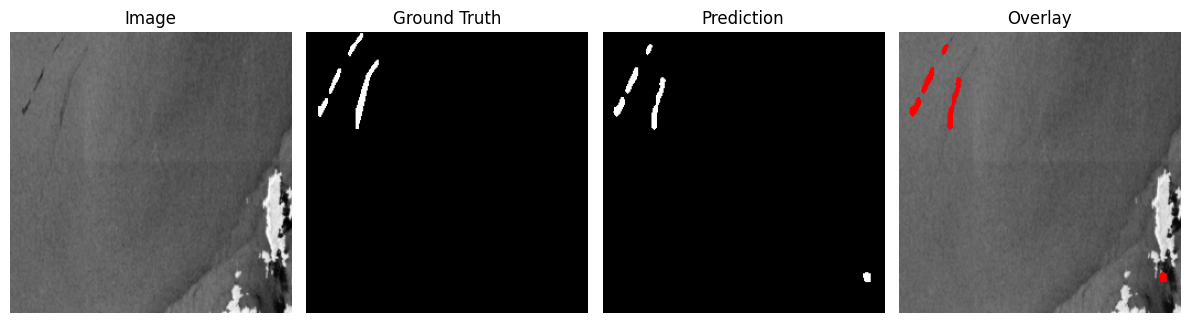

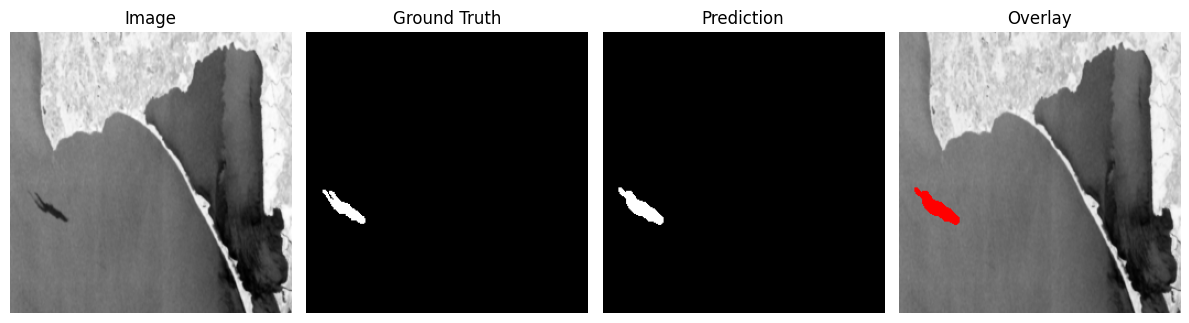

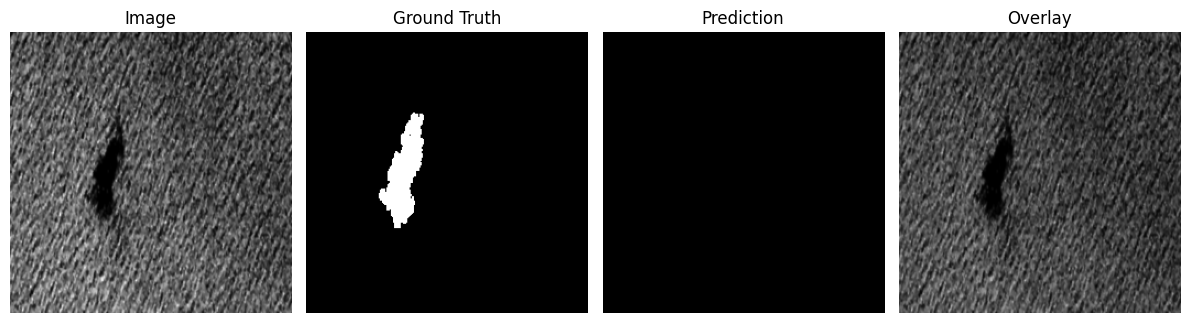

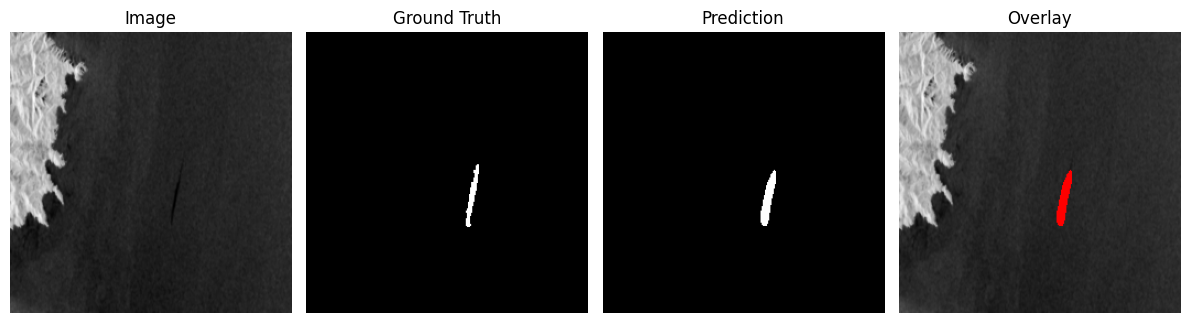

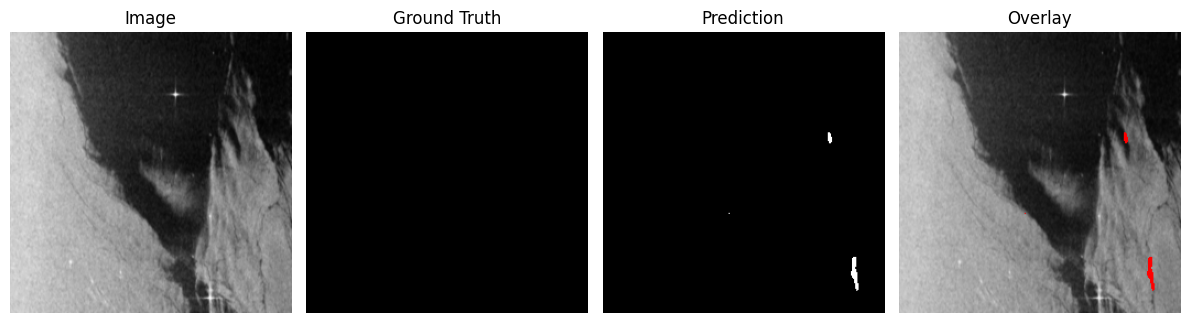

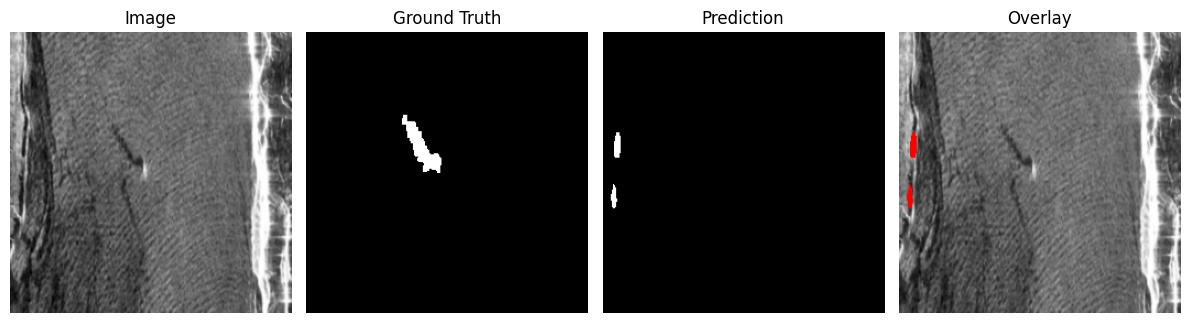

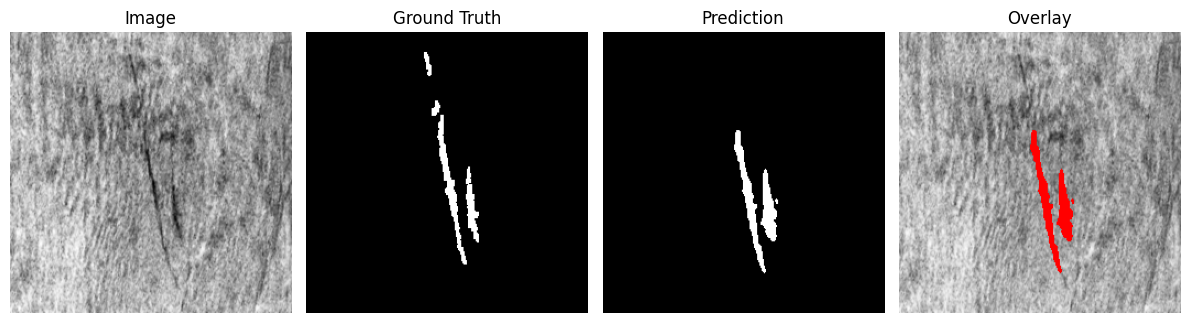

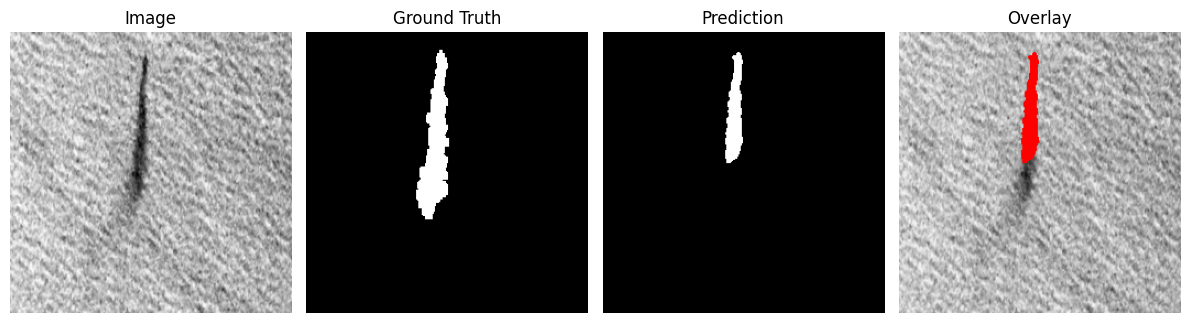

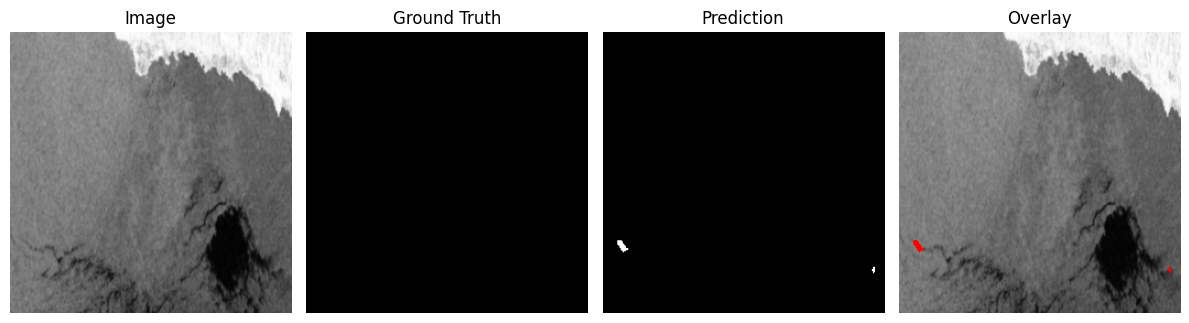

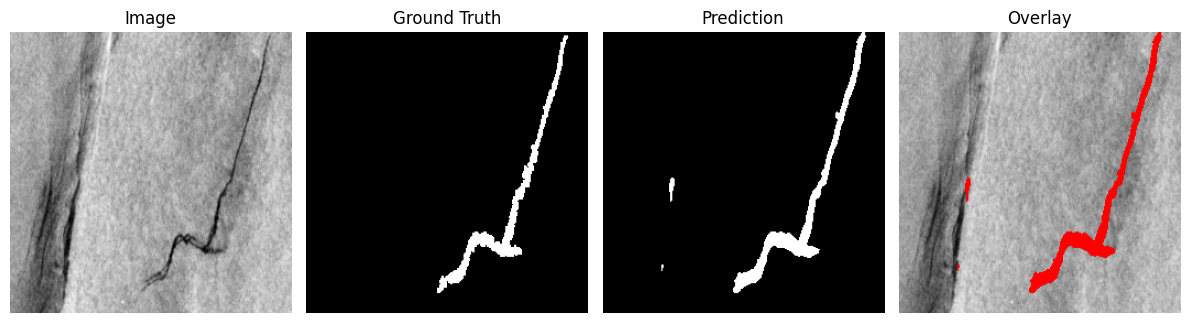

In [19]:
model.eval()

count = 0

with torch.no_grad():

    for images, masks in test_loader:

        images = images.to(device)

        outputs = model(images)
        preds = torch.sigmoid(outputs)
        preds = (preds > 0.4).float()

        for i in range(images.size(0)):

            img = images[i][0].cpu().numpy()
            gt = masks[i][0].cpu().numpy()
            pr = preds[i][0].cpu().numpy()

            # Overlay (oil spill highlighted)
            overlay = img.copy()
            overlay = np.stack([overlay, overlay, overlay], axis=-1)

            overlay[pr == 1] = [1, 0, 0]

            plt.figure(figsize=(12,4))

            plt.subplot(1,4,1)
            plt.imshow(img, cmap="gray")
            plt.title("Image")
            plt.axis("off")

            plt.subplot(1,4,2)
            plt.imshow(gt, cmap="gray")
            plt.title("Ground Truth")
            plt.axis("off")

            plt.subplot(1,4,3)
            plt.imshow(pr, cmap="gray")
            plt.title("Prediction")
            plt.axis("off")

            plt.subplot(1,4,4)
            plt.imshow(overlay)
            plt.title("Overlay")
            plt.axis("off")

            plt.tight_layout()

            plt.show()

            count += 1

            if count == 10:
                break

        if count == 10:
            break